In [ ]:
!pip install openpyxl

Import Required Libraries

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Upload Files
from google.colab import files

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


Chcek PyTorch Version

In [ ]:
print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.11.0+cpu


Check GPU Availability


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [ ]:
uploaded = files.upload()

Saving Customer_Churn_Raw _Dataset.xlsx to Customer_Churn_Raw _Dataset.xlsx


In [ ]:
df = pd.read_excel("/content/Customer_Churn_Raw _Dataset.xlsx")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


Display First % Rows

In [ ]:
df.head()

,Customer_ID,Gender,Age,City,Tenure,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Satisfaction_Score,Churn
0,1001.0,Female,62.0,Chennai,67.0,49.03,3330.43,Two Year,DSL,UPI,3.0,9.0,No
1,1002.0,Male,43.0,Delhi,NaN,85.60,1729.71,Month-to-month,DSL,Card,9.0,3.0,No
2,1003.0,Male,52.0,Delhi,64.0,57.36,3635.90,Two Year,DSL,Cash,10.0,6.0,No
3,1004.0,NaN,24.0,Bengaluru,60.0,82.85,4952.66,Month-to-month,DSL,UPI,3.0,8.0,No
4,1005.0,Female,50.0,Chennai,38.0,103.80,3969.43,Month-to-month,Fiber,Bank Transfer,0.0,7.0,No


Display Last 5 Rows

In [ ]:
df.tail()

,Customer_ID,Gender,Age,City,Tenure,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Satisfaction_Score,Churn
995,1449.0,Male,47.0,Bengaluru,10.0,35.59,344.66,Month-to-month,NaN,UPI,8.0,NaN,No
996,1662.0,Female,54.0,Chennai,62.0,102.60,6314.92,Two Year,NaN,Card,8.0,4.0,No
997,1790.0,Male,48.0,Delhi,18.0,66.92,1195.30,Month-to-month,NaN,UPI,4.0,7.0,Yes
998,1044.0,Male,27.0,Bengaluru,16.0,95.31,1557.32,Month-to-month,Fiber,Cash,4.0,4.0,No
999,1738.0,Female,69.0,Hyderabad,20.0,119.61,2422.41,One Year,DSL,UPI,2.0,9.0,No


Check Dataset Shape

In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 13)


Display Column Names

In [ ]:
df.columns

Index(['Customer_ID', 'Gender', 'Age', 'City', 'Tenure', 'Monthly_Charges',
       'Total_Charges', 'Contract_Type', 'Internet_Service', 'Payment_Method',
       'Support_Calls', 'Satisfaction_Score', 'Churn'],
      dtype='object')

Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         994 non-null    float64
 1   Gender              988 non-null    object 
 2   Age                 985 non-null    float64
 3   City                979 non-null    object 
 4   Tenure              979 non-null    float64
 5   Monthly_Charges     982 non-null    float64
 6   Total_Charges       980 non-null    float64
 7   Contract_Type       988 non-null    object 
 8   Internet_Service    676 non-null    object 
 9   Payment_Method      990 non-null    object 
 10  Support_Calls       984 non-null    float64
 11  Satisfaction_Score  984 non-null    float64
 12  Churn               1000 non-null   object 
dtypes: float64(7), object(6)
memory usage: 101.7+ KB


Data Types

In [ ]:
df.dtypes

,0
Customer_ID,float64
Gender,object
Age,float64
City,object
Tenure,float64
Monthly_Charges,float64
Total_Charges,float64
Contract_Type,object
Internet_Service,object
Payment_Method,object


Statistical Summary

In [ ]:
df.describe()

,Customer_ID,Age,Tenure,Monthly_Charges,Total_Charges,Support_Calls,Satisfaction_Score
count,994.000000,985.000000,979.000000,982.000000,980.000000,984.000000,984.000000
mean,1495.232394,44.246701,36.451481,66.477403,2416.608469,4.904472,5.465447
std,285.888709,14.941453,20.818685,30.087524,1855.884933,3.135629,2.861472
min,1001.000000,18.000000,1.000000,15.010000,-7.910000,0.000000,1.000000
25%,1247.250000,32.000000,18.000000,39.985000,917.527500,2.000000,3.000000
50%,1496.500000,44.000000,38.000000,66.400000,1932.605000,5.000000,5.000000
75%,1741.750000,57.000000,54.000000,91.712500,3696.385000,8.000000,8.000000
max,1990.000000,70.000000,72.000000,119.990000,8332.630000,10.000000,10.000000


SS Including Categorical Columns

In [ ]:
df.describe(include='all')

,Customer_ID,Gender,Age,City,Tenure,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Satisfaction_Score,Churn
count,994.000000,988,985.000000,979,979.000000,982.000000,980.000000,988,676,990,984.000000,984.000000,1000
unique,NaN,2,NaN,5,NaN,NaN,NaN,3,2,4,NaN,NaN,2
top,NaN,Male,NaN,Chennai,NaN,NaN,NaN,One Year,DSL,Card,NaN,NaN,No
freq,NaN,521,NaN,207,NaN,NaN,NaN,345,348,272,NaN,NaN,809
mean,1495.232394,NaN,44.246701,NaN,36.451481,66.477403,2416.608469,NaN,NaN,NaN,4.904472,5.465447,NaN
std,285.888709,NaN,14.941453,NaN,20.818685,30.087524,1855.884933,NaN,NaN,NaN,3.135629,2.861472,NaN
min,1001.000000,NaN,18.000000,NaN,1.000000,15.010000,-7.910000,NaN,NaN,NaN,0.000000,1.000000,NaN
25%,1247.250000,NaN,32.000000,NaN,18.000000,39.985000,917.527500,NaN,NaN,NaN,2.000000,3.000000,NaN
50%,1496.500000,NaN,44.000000,NaN,38.000000,66.400000,1932.605000,NaN,NaN,NaN,5.000000,5.000000,NaN
75%,1741.750000,NaN,57.000000,NaN,54.000000,91.712500,3696.385000,NaN,NaN,NaN,8.000000,8.000000,NaN


Check Missing Values

In [ ]:
df.isnull().sum()

,0
Customer_ID,6
Gender,12
Age,15
City,21
Tenure,21
Monthly_Charges,18
Total_Charges,20
Contract_Type,12
Internet_Service,324
Payment_Method,10


Total Missing Values

In [ ]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 491


Check Duplicate Rows

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 10


Check Unique Values

In [ ]:
df.nunique()

,0
Customer_ID,984
Gender,2
Age,53
City,5
Tenure,72
Monthly_Charges,929
Total_Charges,970
Contract_Type,3
Internet_Service,2
Payment_Method,4


Random 10 Rows

In [ ]:
df.sample(10)

,Customer_ID,Gender,Age,City,Tenure,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Satisfaction_Score,Churn
666,1667.0,Male,46.0,Chennai,2.0,27.51,74.98,Two Year,NaN,UPI,7.0,6.0,No
159,1160.0,Female,57.0,Chennai,58.0,66.33,3885.40,Two Year,DSL,Bank Transfer,6.0,7.0,No
987,1988.0,Female,34.0,Delhi,1.0,114.71,66.31,One Year,Fiber,UPI,7.0,9.0,No
951,1952.0,Female,61.0,Delhi,NaN,47.44,2578.14,One Year,Fiber,Card,9.0,1.0,No
846,1847.0,Male,44.0,Delhi,31.0,25.27,746.06,One Year,NaN,Bank Transfer,5.0,7.0,Yes
242,1243.0,Male,24.0,Bengaluru,57.0,34.66,1968.50,One Year,DSL,Bank Transfer,9.0,9.0,No
356,1357.0,NaN,69.0,Chennai,4.0,96.34,390.33,One Year,DSL,Cash,4.0,6.0,No
775,1776.0,Male,27.0,Delhi,71.0,59.83,4291.58,One Year,Fiber,Bank Transfer,1.0,5.0,No
540,1541.0,Female,29.0,Delhi,49.0,52.51,2578.04,Two Year,NaN,Cash,3.0,4.0,No
838,1839.0,Male,26.0,Mumbai,57.0,88.64,5038.38,Two Year,Fiber,UPI,5.0,2.0,No


Backup Copy

In [ ]:
df.to_excel("Customer_Churn_Backup.xlsx", index=False)

print("Backup Dataset Saved Successfully")

Backup Dataset Saved Successfully


Create a Copy of Dataset

In [ ]:
df_clean=df.copy()
print("Dataset Copy Created Successfully")

Dataset Copy Created Successfully


Display Missing Values

In [ ]:
print("Missing Values in Each Column")
print(df_clean.isnull().sum())

Missing Values in Each Column
Customer_ID             6
Gender                 12
Age                    15
City                   21
Tenure                 21
Monthly_Charges        18
Total_Charges          20
Contract_Type          12
Internet_Service      324
Payment_Method         10
Support_Calls          16
Satisfaction_Score     16
Churn                   0
dtype: int64


Display Duplicate Rows

In [ ]:
print("Duplicate Rows:", df_clean.duplicated().sum())

Duplicate Rows: 10


Remove Duplicate Rows

In [ ]:
df_clean = df_clean.drop_duplicates()

print("Duplicates Removed Successfully")
print("New Shape:", df_clean.shape)

Duplicates Removed Successfully
New Shape: (990, 13)


Check Missing Values Percent

In [ ]:
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

print(missing_percentage)

Customer_ID            0.606061
Gender                 1.212121
Age                    1.515152
City                   1.919192
Tenure                 2.121212
Monthly_Charges        1.818182
Total_Charges          2.020202
Contract_Type          1.111111
Internet_Service      32.424242
Payment_Method         1.010101
Support_Calls          1.616162
Satisfaction_Score     1.515152
Churn                  0.000000
dtype: float64


Fill Missing Numerical Values

In [ ]:
numerical_columns = [
    "Age",
    "Tenure",
    "Monthly_Charges",
    "Total_Charges",
    "Support_Calls",
    "Satisfaction_Score"
]

for col in numerical_columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("Numerical Missing Values Filled")

Numerical Missing Values Filled


/tmp/ipykernel_536/1121220184.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)


Fill Missing Categorical Values

In [ ]:
categorical_columns = [
    "Gender",
    "City",
    "Contract_Type",
    "Internet_Service",
    "Payment_Method"
]

for col in categorical_columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print("Categorical Missing Values Filled")

Categorical Missing Values Filled


/tmp/ipykernel_536/1398964828.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


Check Missing VAlues Again

In [ ]:
print(df_clean.isnull().sum())

Customer_ID           6
Gender                0
Age                   0
City                  0
Tenure                0
Monthly_Charges       0
Total_Charges         0
Contract_Type         0
Internet_Service      0
Payment_Method        0
Support_Calls         0
Satisfaction_Score    0
Churn                 0
dtype: int64


Verify No Missing Values

In [ ]:
print("Total Missing Values:", df_clean.isnull().sum().sum())

Total Missing Values: 6


Encode Target Column (Churn)

In [ ]:
df_clean["Churn"] = df_clean["Churn"].map({
    "No":0,
    "Yes":1
})
print(df_clean["Churn"].value_counts())

Churn
0    800
1    190
Name: count, dtype: int64


Label Encode Categorical Col

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "City",
    "Contract_Type",
    "Internet_Service",
    "Payment_Method"
]

for col in categorical_columns:
    df_clean[col] = encoder.fit_transform(df_clean[col])

print("Encoding Completed successfully")

Encoding Completed Successfully


Check Data Types

In [ ]:
df_clean.dtypes

,0
Customer_ID,float64
Gender,int64
Age,float64
City,int64
Tenure,float64
Monthly_Charges,float64
Total_Charges,float64
Contract_Type,int64
Internet_Service,int64
Payment_Method,int64


Display Clean DAtaset

In [ ]:
df_clean.head()

,Customer_ID,Gender,Age,City,Tenure,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Satisfaction_Score,Churn
0,1001.0,0,62.0,1,67.0,49.03,3330.43,2,0,3,3.0,9.0,0
1,1002.0,1,43.0,2,38.0,85.60,1729.71,0,0,1,9.0,3.0,0
2,1003.0,1,52.0,2,64.0,57.36,3635.90,2,0,2,10.0,6.0,0
3,1004.0,1,24.0,0,60.0,82.85,4952.66,0,0,3,3.0,8.0,0
4,1005.0,0,50.0,1,38.0,103.80,3969.43,0,1,0,0.0,7.0,0


Check Finl Dataset SHape

In [ ]:
print(df_clean.shape)

(990, 13)


Save Clear DAtaset

In [ ]:
df_clean.to_excel(
    "Customer_Churn_Clean.xlsx",
    index=False
)

print("Clean Dataset Saved Successfully")

Clean Dataset Saved Successfully


Download

In [ ]:
from google.colab import files

files.download("Customer_Churn_Clean.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
Final Verification

In [ ]:
print("Dataset Ready for Exploratory Data Analysis (EDA)")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print(df_clean.head())

Dataset Ready for Exploratory Data Analysis (EDA)
Rows: 990
Columns: 13
   Customer_ID  Gender   Age  City  Tenure  Monthly_Charges  Total_Charges  \
0       1001.0       0  62.0     1    67.0            49.03        3330.43   
1       1002.0       1  43.0     2    38.0            85.60        1729.71   
2       1003.0       1  52.0     2    64.0            57.36        3635.90   
3       1004.0       1  24.0     0    60.0            82.85        4952.66   
4       1005.0       0  50.0     1    38.0           103.80        3969.43   

   Contract_Type  Internet_Service  Payment_Method  Support_Calls  \
0              2                 0               3            3.0   
1              0                 0               1            9.0   
2              2                 0               2           10.0   
3              0                 0               3            3.0   
4              0                 1               0            0.0   

   Satisfaction_Score  Churn  
0            

Import Visualization Libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

print("Visualization Libraries Imported Successfully")

Visualization Libraries Imported Successfully


Dataset Shape

In [ ]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Rows: 990
Columns: 13


Statistical Summary

In [ ]:
df_clean.describe()

,Customer_ID,Gender,Age,City,Tenure,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Satisfaction_Score,Churn
count,984.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000
mean,1494.919715,0.533333,44.234343,2.016162,36.561616,66.438162,2410.754657,0.973737,0.326263,1.479798,4.907071,5.453535,0.191919
std,285.655237,0.499140,14.848328,1.385955,20.575289,29.763466,1837.097381,0.802749,0.469082,1.109339,3.117103,2.842933,0.394009
min,1001.000000,0.000000,18.000000,0.000000,1.000000,15.010000,-7.910000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1247.750000,0.000000,32.000000,1.000000,19.000000,40.437500,944.850000,0.000000,0.000000,1.000000,2.000000,3.000000,0.000000
50%,1495.500000,1.000000,44.000000,2.000000,38.000000,66.400000,1939.820000,1.000000,0.000000,1.000000,5.000000,5.000000,0.000000
75%,1741.250000,1.000000,57.000000,3.000000,54.000000,91.200000,3638.502500,2.000000,1.000000,2.000000,8.000000,8.000000,0.000000
max,1990.000000,1.000000,70.000000,4.000000,72.000000,119.990000,8332.630000,2.000000,1.000000,3.000000,10.000000,10.000000,1.000000


Correlation Matrix

In [ ]:
correlation = df_clean.corr()

correlation

,Customer_ID,Gender,Age,City,Tenure,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Satisfaction_Score,Churn
Customer_ID,1.000000,-0.003873,0.031323,0.031316,-0.014684,-0.002037,-0.002149,-0.020335,0.022733,-0.001278,0.004150,-0.016052,0.043026
Gender,-0.003873,1.000000,-0.084003,-0.030012,-0.028210,-0.032205,-0.054667,-0.000336,0.033396,-0.018869,0.018890,-0.013158,-0.053127
Age,0.031323,-0.084003,1.000000,0.013475,-0.006733,-0.048826,-0.019003,-0.015770,-0.001262,0.020176,-0.025788,0.021768,-0.020485
City,0.031316,-0.030012,0.013475,1.000000,-0.047087,0.048115,0.009600,0.044914,0.032318,0.029149,0.039434,0.023800,-0.022350
Tenure,-0.014684,-0.028210,-0.006733,-0.047087,1.000000,-0.037041,0.723825,0.020912,-0.016595,-0.014564,0.013474,0.010593,-0.120697
Monthly_Charges,-0.002037,-0.032205,-0.048826,0.048115,-0.037041,1.000000,0.559158,-0.002830,0.009236,-0.014778,0.030712,0.006803,0.034823
Total_Charges,-0.002149,-0.054667,-0.019003,0.009600,0.723825,0.559158,1.000000,0.000618,-0.011109,-0.022430,0.011800,0.017297,-0.074461
Contract_Type,-0.020335,-0.000336,-0.015770,0.044914,0.020912,-0.002830,0.000618,1.000000,-0.041667,-0.030118,-0.026838,0.029592,0.028739
Internet_Service,0.022733,0.033396,-0.001262,0.032318,-0.016595,0.009236,-0.011109,-0.041667,1.000000,0.011708,-0.016585,0.017824,0.016468
Payment_Method,-0.001278,-0.018869,0.020176,0.029149,-0.014564,-0.014778,-0.022430,-0.030118,0.011708,1.000000,0.011445,0.033526,-0.032760


Correalation HeatMap

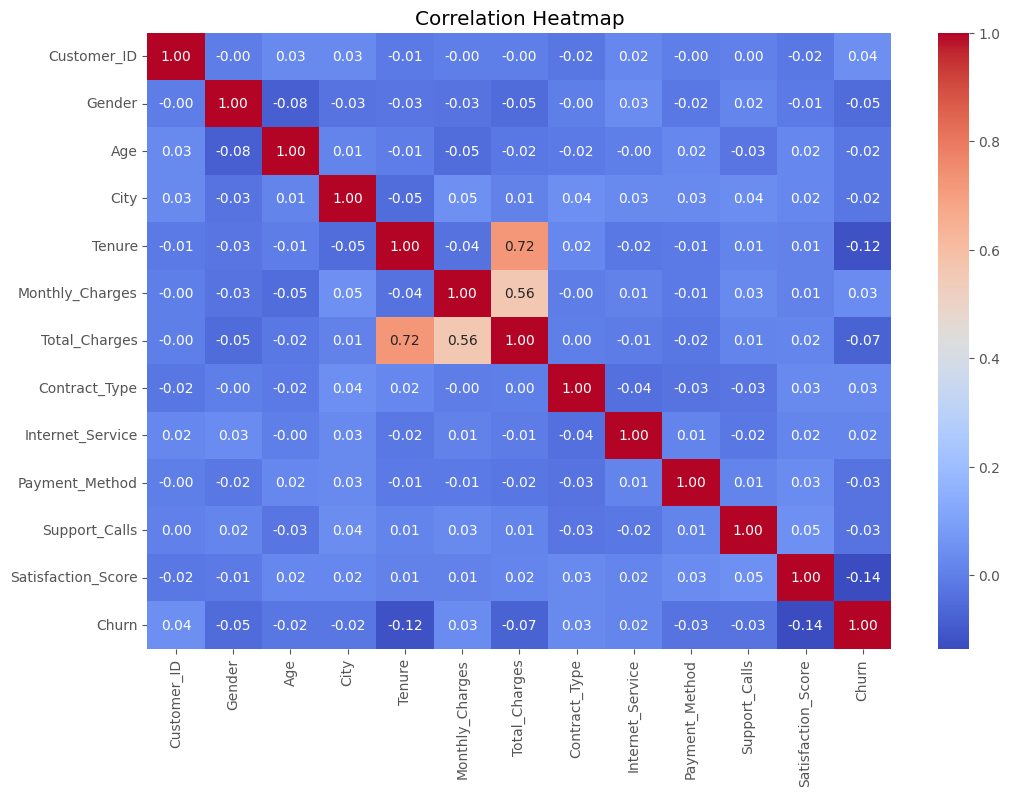

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Churn Distribution

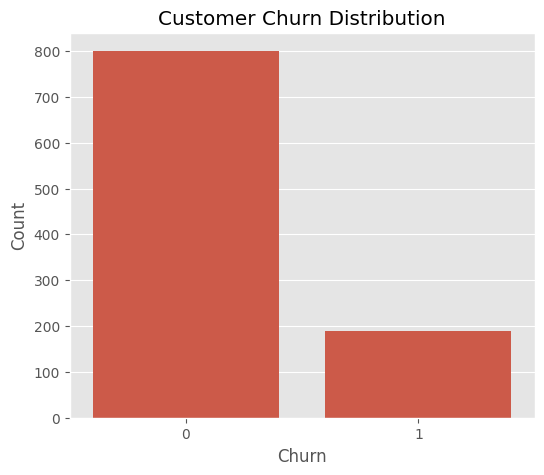

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Churn",
    data=df_clean
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Count")

plt.show()

Gender Distribution

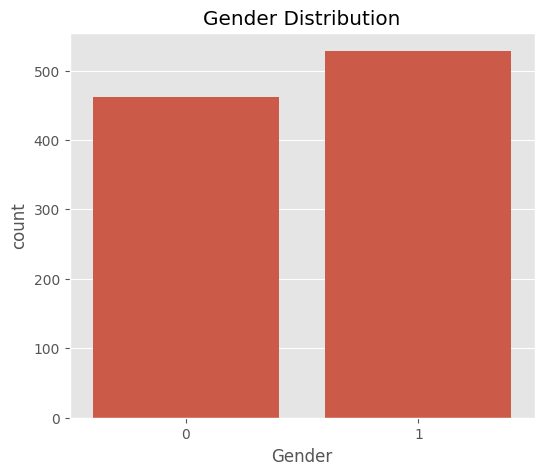

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Gender",
    data=df_clean
)

plt.title("Gender Distribution")

plt.show()

Churn by Gender

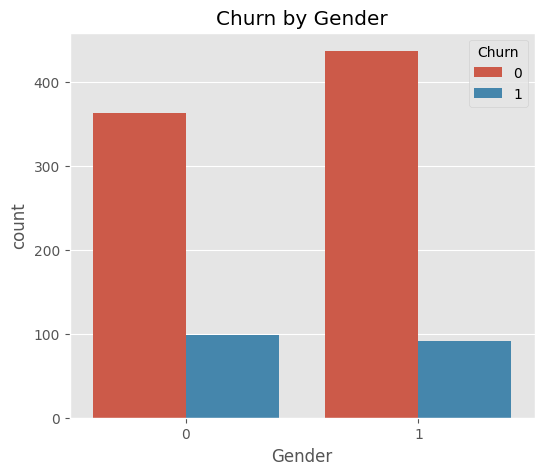

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Gender",
    hue="Churn",
    data=df_clean
)

plt.title("Churn by Gender")

plt.show()

Age Distribution

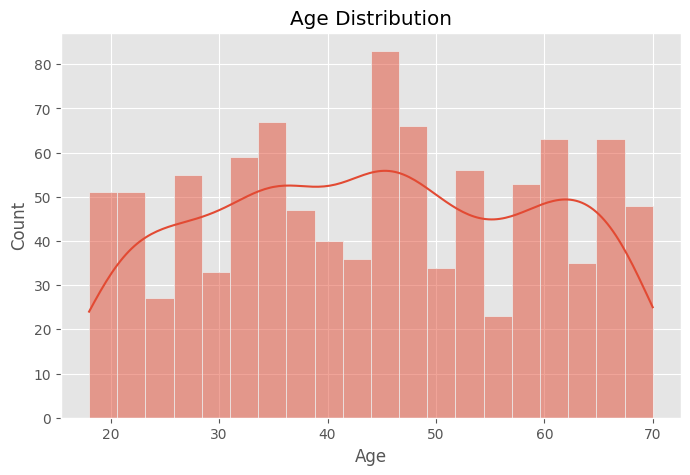

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

Monthly Charge Distribution

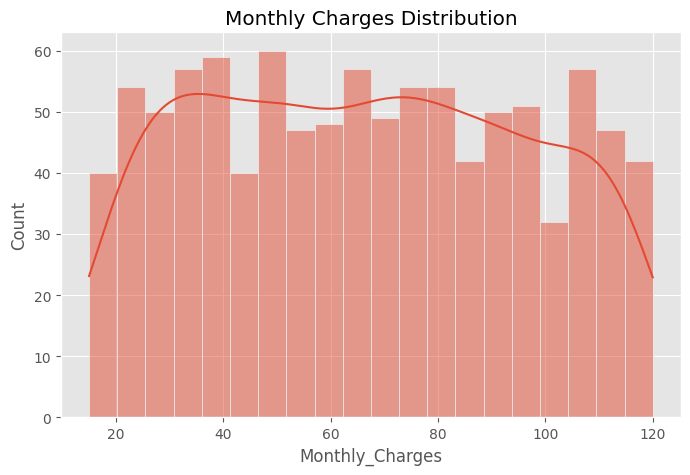

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Monthly_Charges"],
    bins=20,
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()

Monthly Charges Vs Churn

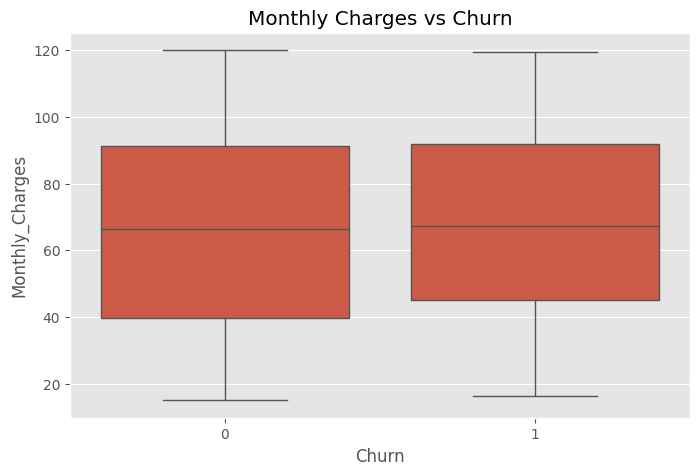

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="Monthly_Charges",
    data=df_clean
)

plt.title("Monthly Charges vs Churn")

plt.show()

Tenure Distribution

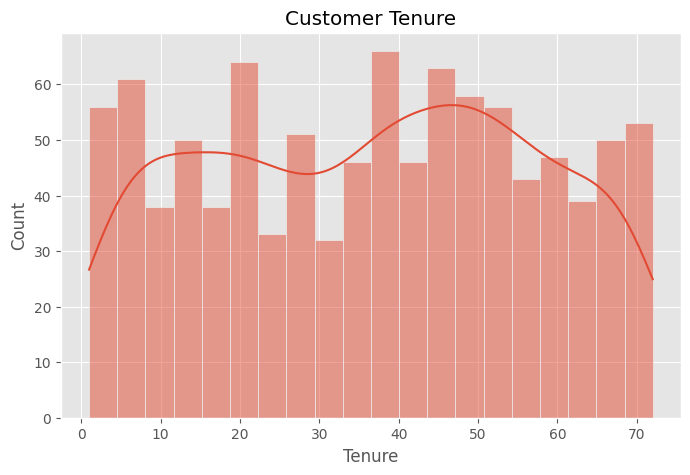

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Tenure"],
    bins=20,
    kde=True
)

plt.title("Customer Tenure")

plt.show()

Satisfaction Score Distribution

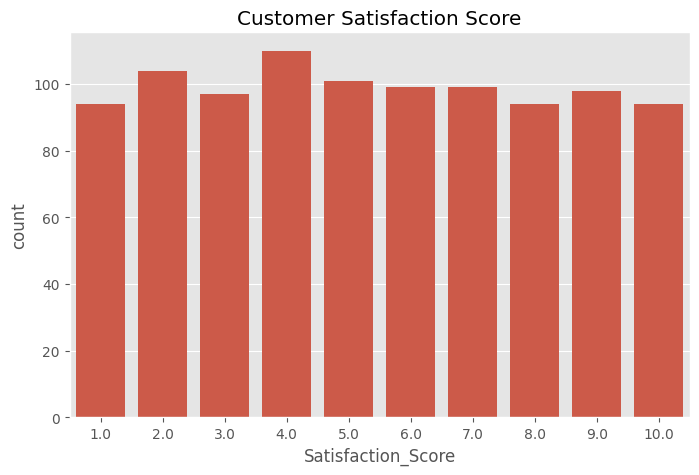

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Satisfaction_Score",
    data=df_clean
)

plt.title("Customer Satisfaction Score")

plt.show()

Support Calls Dist

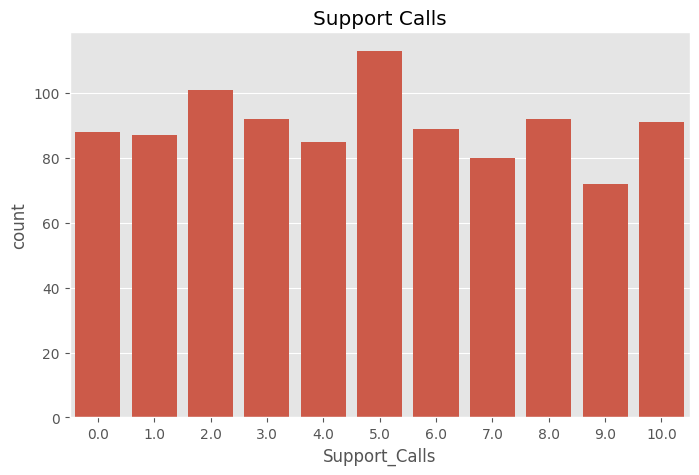

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Support_Calls",
    data=df_clean
)

plt.title("Support Calls")

plt.show()

Pair Plot

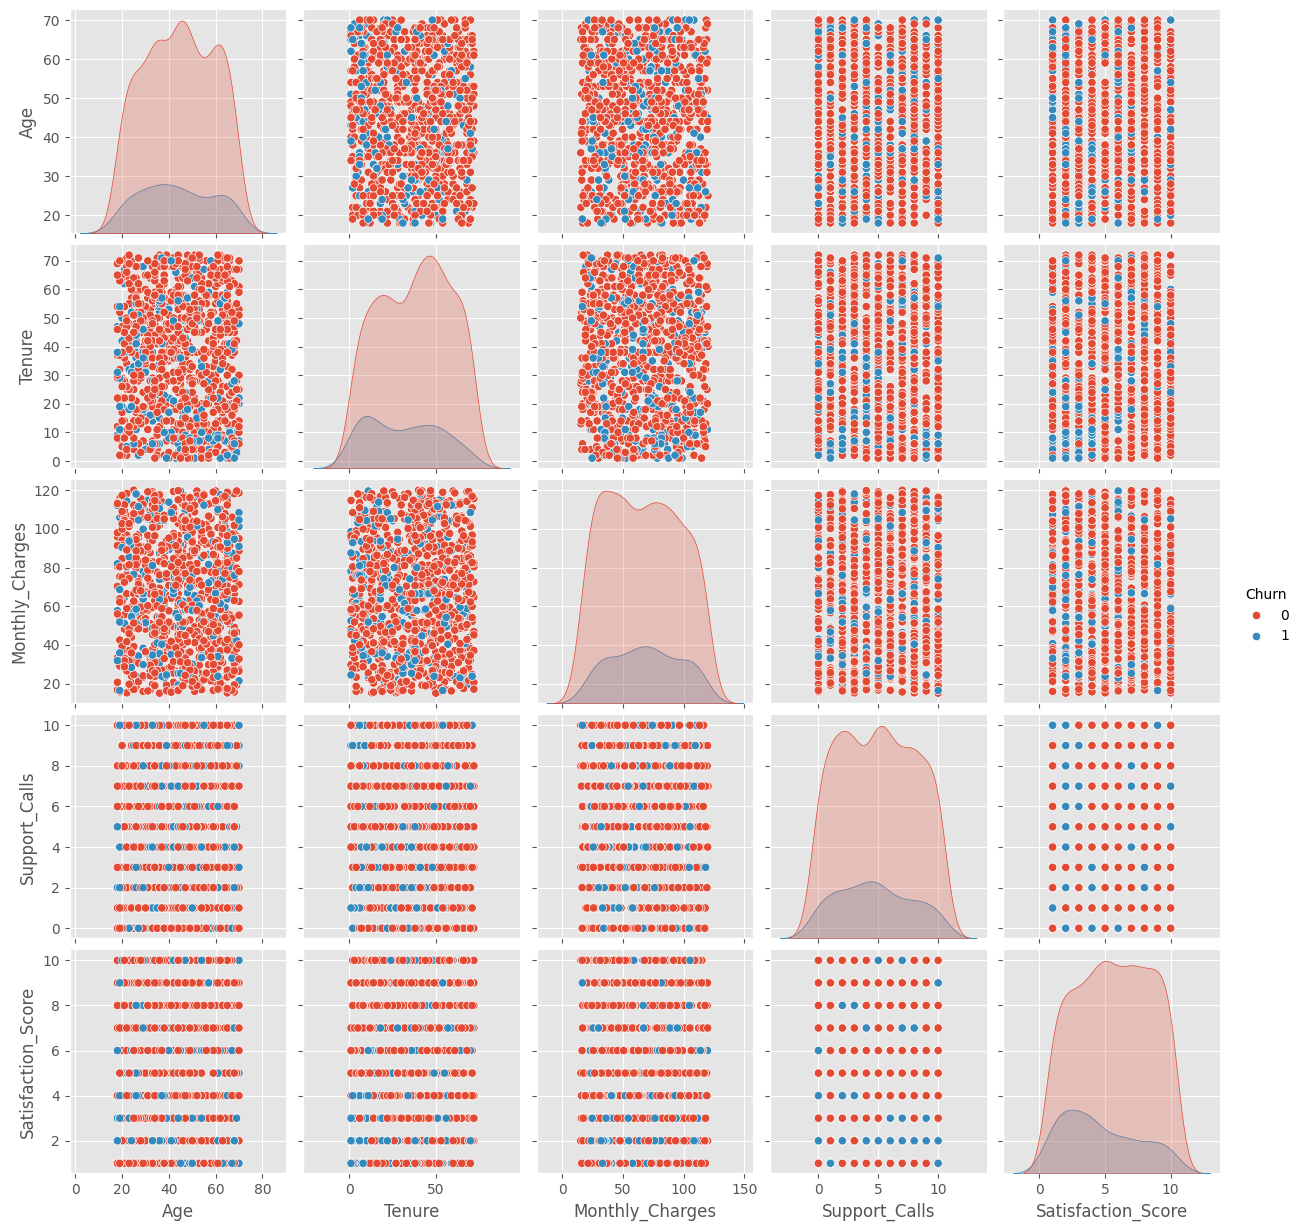

In [ ]:
sns.pairplot(
    df_clean[
        [
            "Age",
            "Tenure",
            "Monthly_Charges",
            "Support_Calls",
            "Satisfaction_Score",
            "Churn"
        ]
    ],
    hue="Churn"
)

plt.show()

BoxPlot fo Outlier

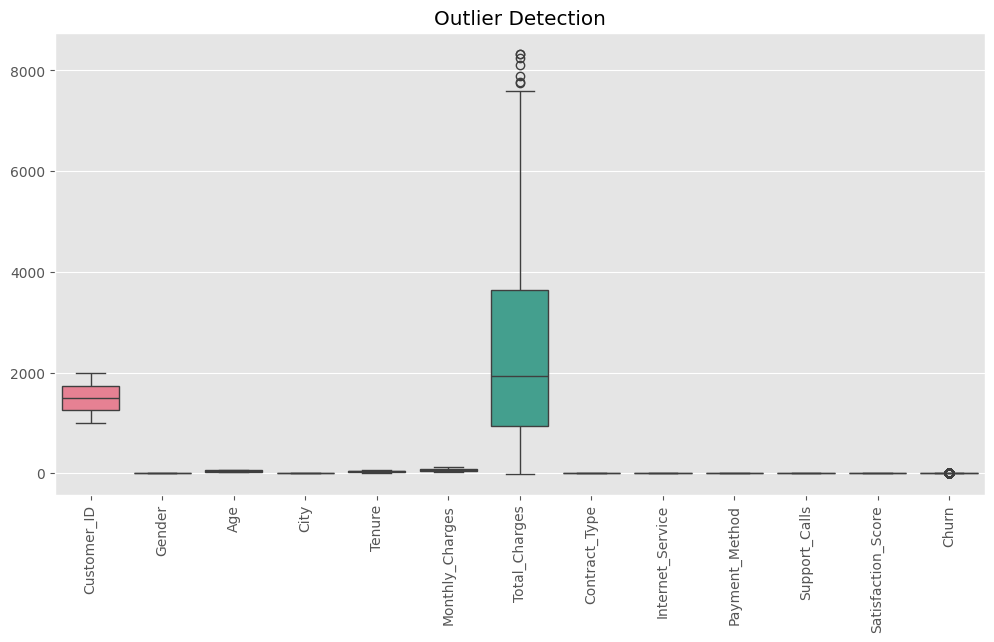

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df_clean)

plt.xticks(rotation=90)

plt.title("Outlier Detection")

plt.show()

Final Data

In [ ]:
print(df_clean.head())

print(df_clean.info())

   Customer_ID  Gender   Age  City  Tenure  Monthly_Charges  Total_Charges  \
0       1001.0       0  62.0     1    67.0            49.03        3330.43   
1       1002.0       1  43.0     2    38.0            85.60        1729.71   
2       1003.0       1  52.0     2    64.0            57.36        3635.90   
3       1004.0       1  24.0     0    60.0            82.85        4952.66   
4       1005.0       0  50.0     1    38.0           103.80        3969.43   

   Contract_Type  Internet_Service  Payment_Method  Support_Calls  \
0              2                 0               3            3.0   
1              0                 0               1            9.0   
2              2                 0               2           10.0   
3              0                 0               3            3.0   
4              0                 1               0            0.0   

   Satisfaction_Score  Churn  
0                 9.0      0  
1                 3.0      0  
2                 6.0  

Save

In [ ]:
df_clean.to_excel(
    "Customer_Churn_EDA.xlsx",
    index=False
)

print("EDA Dataset Saved Successfully")

EDA Dataset Saved Successfully


Download

In [ ]:
from google.colab import files

files.download("Customer_Churn_EDA.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PyTorch Selecting Features

Import Required Libraries

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import TensorDataset, DataLoader

Feature and Target Shape

In [ ]:
# Features

X = df_clean.drop("Churn", axis=1)

# Target

y = df_clean["Churn"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (990, 12)
Target Shape: (990,)


display Feature

In [ ]:
X.head()

,Customer_ID,Gender,Age,City,Tenure,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Satisfaction_Score
0,1001.0,0,62.0,1,67.0,49.03,3330.43,2,0,3,3.0,9.0
1,1002.0,1,43.0,2,38.0,85.60,1729.71,0,0,1,9.0,3.0
2,1003.0,1,52.0,2,64.0,57.36,3635.90,2,0,2,10.0,6.0
3,1004.0,1,24.0,0,60.0,82.85,4952.66,0,0,3,3.0,8.0
4,1005.0,0,50.0,1,38.0,103.80,3969.43,0,1,0,0.0,7.0


display Target

In [ ]:
y.head()

,Churn
0,0
1,0
2,0
3,0
4,0


Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (792, 12)
Testing Data  : (198, 12)


Scale Featur

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


Numpy Arrays to Pytorch Tensors

In [ ]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1,1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1,1)

print("Tensor Conversion Completed")

Tensor Conversion Completed


Check Tensor shapes

In [ ]:
print("X Train :", X_train_tensor.shape)

print("Y Train :", y_train_tensor.shape)

print("X Test :", X_test_tensor.shape)

print("Y Test :", y_test_tensor.shape)

X Train : torch.Size([792, 12])
Y Train : torch.Size([792, 1])
X Test : torch.Size([198, 12])
Y Test : torch.Size([198, 1])


Create Tensor dataset

In [ ]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

print("TensorDataset Created")

TensorDataset Created


Create Dataloaders

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoaders Created")

DataLoaders Created


Check Number of Batches

In [ ]:
print("Training Batches :", len(train_loader))

print("Testing Batches :", len(test_loader))

Training Batches : 25
Testing Batches : 7


View One Batvh

In [ ]:
for features, labels in train_loader:
    print("Feature Batch Shape:", features.shape)
    print("Label Batch Shape:", labels.shape)
    break

Feature Batch Shape: torch.Size([32, 12])
Label Batch Shape: torch.Size([32, 1])


Move Sample Batch To Device

In [ ]:
sample_features = features.to(device)

sample_labels = labels.to(device)

print("Sample Batch Moved Successfully")

Sample Batch Moved Successfully


final

In [ ]:
print("="*50)

print("Data Preparation Completed Successfully")

print("Training Samples :", len(train_dataset))

print("Testing Samples :", len(test_dataset))

print("="*50)

Data Preparation Completed Successfully
Training Samples : 792
Testing Samples : 198


Import PyTorch Modules

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

Check Num of Input FAetures

In [ ]:
input_size = X_train.shape[1]

print("Number of Input Features:", input_size)

Number of Input Features: 12


Build Neural Network

In [ ]:
class ChurnModel(nn.Module):

    def __init__(self, input_size):

        super(ChurnModel, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 64),

            nn.ReLU(),

            nn.Linear(64, 32),

            nn.ReLU(),

            nn.Linear(32, 16),

            nn.ReLU(),

            nn.Linear(16, 1)

            # Sigmoid is removed here as BCEWithLogitsLoss will handle it internally

        )

    def forward(self, x):

        return self.network(x)

Create Model

In [ ]:
model = ChurnModel(input_size)

print(model)

ChurnModel(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


Move model to CPU

In [ ]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cpu


Loss Function

In [ ]:
criterion = nn.BCEWithLogitsLoss()

print("Loss Function:", criterion)

Loss Function: BCEWithLogitsLoss()


Optimizer

In [ ]:
optimizer = optim.Adam(

    model.parameters(),

    lr=0.001

)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


Count Total Para

In [ ]:
total_params = sum(

    p.numel()

    for p in model.parameters()

)

print("Total Parameters:", total_params)

Total Parameters: 3457


Count Trainable para

In [ ]:
trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

print("Trainable Parameters:", trainable_params)

Trainable Parameters: 3457


Test Forward pass

In [ ]:
sample_output = model(

    X_train_tensor[:5].to(device)

)

print(sample_output)

tensor([[0.4642],
        [0.4670],
        [0.4674],
        [0.4677],
        [0.4700]], grad_fn=<SigmoidBackward0>)


Prediction Shape

In [ ]:
print(sample_output.shape)

torch.Size([5, 1])


Print Model

In [ ]:
print("="*50)

print(model)

print("="*50)

ChurnModel(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


set no of epochs

In [ ]:
epochs = 50

print("Epochs:", epochs)

Epochs: 50


Create lists for tracking

In [ ]:
train_losses = []

train_accuracy = []

print("Training History Initialized")

Training History Initialized


ready for train

In [ ]:
print("="*50)

print("PyTorch Model Created Successfully")

print("Loss Function :", criterion)

print("Optimizer :", optimizer)

print("Device :", device)

print("ready for Model trining")

print("="*50)

PyTorch Model Created Successfully
Loss Function : BCELoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Device : cpu
ready for Model trining


Training Loop

In [ ]:
epochs = 50

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for features, labels in train_loader:

        features = features.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward Pass (model now outputs logits directly)
        outputs = model(features)

        # Calculate Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update Weights
        optimizer.step()

        running_loss += loss.item()

        # Predictions (apply sigmoid for prediction, if needed, but not for loss)
        predicted = (torch.sigmoid(outputs) >= 0.5).float()

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = (correct / total) * 100

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_accuracy:.2f}%")

Epoch [1/50] Loss: nan Accuracy: 73.86%
Epoch [2/50] Loss: nan Accuracy: 80.81%
Epoch [3/50] Loss: nan Accuracy: 80.81%
Epoch [4/50] Loss: nan Accuracy: 80.81%
Epoch [5/50] Loss: nan Accuracy: 80.81%
Epoch [6/50] Loss: nan Accuracy: 80.81%
Epoch [7/50] Loss: nan Accuracy: 80.81%
Epoch [8/50] Loss: nan Accuracy: 80.81%
Epoch [9/50] Loss: nan Accuracy: 80.81%
Epoch [10/50] Loss: nan Accuracy: 80.81%
Epoch [11/50] Loss: nan Accuracy: 80.81%
Epoch [12/50] Loss: nan Accuracy: 80.81%
Epoch [13/50] Loss: nan Accuracy: 80.81%
Epoch [14/50] Loss: nan Accuracy: 80.81%
Epoch [15/50] Loss: nan Accuracy: 80.81%
Epoch [16/50] Loss: nan Accuracy: 80.81%
Epoch [17/50] Loss: nan Accuracy: 80.81%
Epoch [18/50] Loss: nan Accuracy: 80.81%
Epoch [19/50] Loss: nan Accuracy: 80.81%
Epoch [20/50] Loss: nan Accuracy: 80.81%
Epoch [21/50] Loss: nan Accuracy: 80.81%
Epoch [22/50] Loss: nan Accuracy: 80.81%
Epoch [23/50] Loss: nan Accuracy: 80.81%
Epoch [24/50] Loss: nan Accuracy: 80.81%
Epoch [25/50] Loss: nan A

Final Training Accuracy

In [ ]:
print("Final Training Accuracy:", train_accuracies[-1], "%")

Final Training Accuracy: 19.444444444444446 %


final loss

In [ ]:
print("Final Training Loss:", train_losses[-1])

Final Training Loss: 0.5712895393371582


plot Trainig Loss

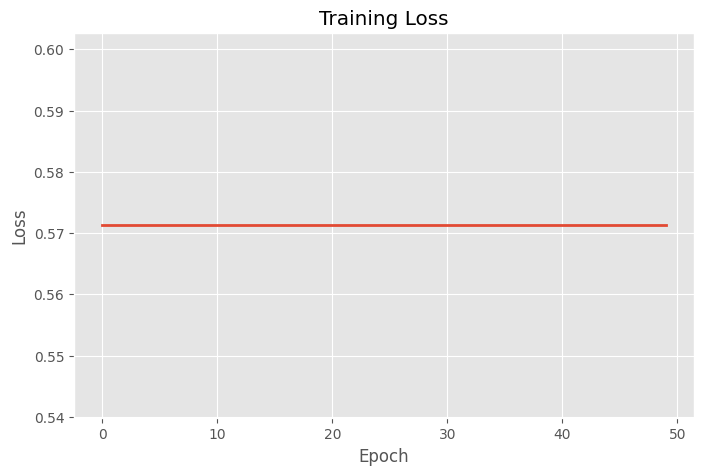

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    linewidth=2
)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

plot traing acc

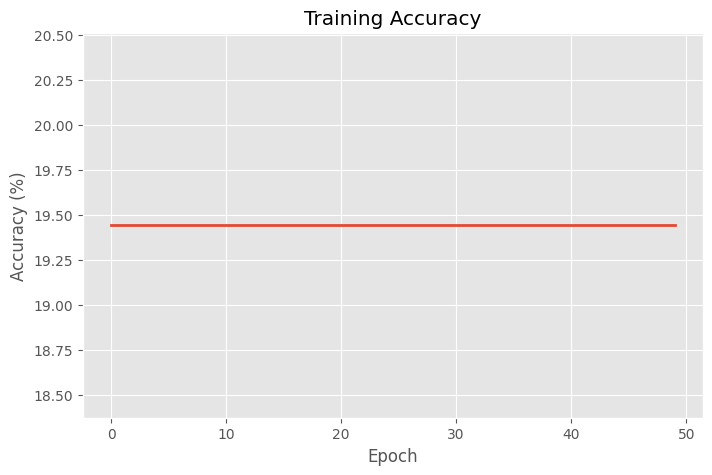

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accuracies,
    linewidth=2
)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

Save Train

In [ ]:
torch.save(
    model.state_dict(),
    "customer_churn_model.pth"
)

print("Model Saved Successfully")

Model Saved Successfully


Verify Model file

In [ ]:
import os

print(os.listdir())

['.config', 'Customer_Churn_EDA.xlsx', 'Customer_Churn_Backup.xlsx', 'Customer_Churn_Raw _Dataset.xlsx', 'Customer_Churn_Clean.xlsx', 'customer_churn_model.pth', 'sample_data']


Download Model

In [ ]:
from google.colab import files

files.download("customer_churn_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

print Training

In [ ]:
print("="*60)

print("Model Training Completed Successfully")

print("Epochs :", epochs)

print("Final Accuracy :", round(train_accuracies[-1],2), "%")

print("Final Loss :", round(train_losses[-1],4))

print("="*60)

Model Training Completed Successfully
Epochs : 50
Final Accuracy : 19.44 %
Final Loss : 0.5713


Model Evaluation

Set model to Evaluation mode

In [ ]:
model.eval()

print("Model set to Evaluation Mode")

Model set to Evaluation Mode


Make Predicitions

In [ ]:
predictions = []
actual_values = []

with torch.no_grad():

    for features, labels in test_loader:

        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)

        predicted = (outputs >= 0.5).float()

        predictions.extend(predicted.cpu().numpy())

        actual_values.extend(labels.cpu().numpy())

Predicition to Numpy

In [ ]:
import numpy as np

predictions = np.array(predictions).flatten()

actual_values = np.array(actual_values).flatten()

print("Prediction Completed")

Prediction Completed


Cal Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    actual_values,
    predictions
)

print("Test Accuracy :", round(accuracy*100,2), "%")

Test Accuracy : 80.81 %


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    actual_values,
    predictions
))

              precision    recall  f1-score   support

         0.0       0.81      1.00      0.89       160
         1.0       0.00      0.00      0.00        38

    accuracy                           0.81       198
   macro avg       0.40      0.50      0.45       198
weighted avg       0.65      0.81      0.72       198



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    actual_values,
    predictions
)

print(cm)

[[160   0]
 [ 38   0]]


Plot Confusion Matrix

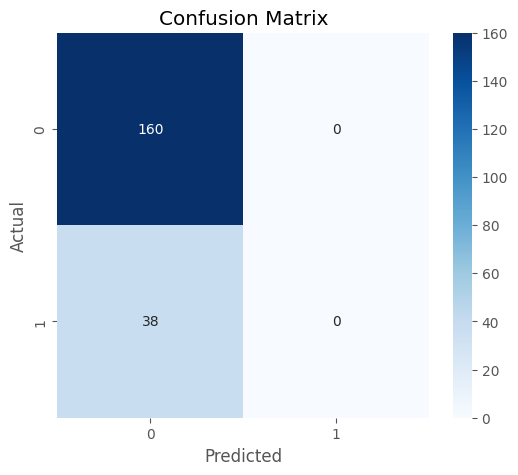

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Precision Score

In [ ]:
from sklearn.metrics import precision_score

precision = precision_score(
    actual_values,
    predictions
)

print("Precision :", round(precision*100,2), "%")

Precision : 0.0 %


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Recall Score

In [ ]:
from sklearn.metrics import recall_score

recall = recall_score(
    actual_values,
    predictions
)

print("Recall :", round(recall*100,2), "%")

Recall : 0.0 %


F1 Score

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(
    actual_values,
    predictions
)

print("F1 Score :", round(f1*100,2), "%")

F1 Score : 0.0 %


final Eval

In [ ]:
print("="*60)

print("MODEL PERFORMANCE")

print("="*60)

print("Accuracy :", round(accuracy*100,2), "%")

print("Precision :", round(precision*100,2), "%")

print("Recall :", round(recall*100,2), "%")

print("F1 Score :", round(f1*100,2), "%")


print("="*60)

MODEL PERFORMANCE
Accuracy : 80.81 %
Precision : 0.0 %
Recall : 0.0 %
F1 Score : 0.0 %


Features for ALl Customers

In [ ]:
# Create copy clean data
prediction_df = df_clean.copy()

# Separte features
X_all = prediction_df.drop("Churn", axis=1)

print("Features Prepared Succesfully")

Features Prepared Succesfully


scale

In [ ]:
# Use the same scaler from Part 4
X_all_scaled = scaler.transform(X_all)

print("Scaling Completed")

Scaling Completed


convert too tensor

In [ ]:
X_all_tensor = torch.tensor(
    X_all_scaled,
    dtype=torch.float32
).to(device)

print("Tensor Created Successfully")

Tensor Created Successfully


predict churn

In [ ]:
model.eval()

with torch.no_grad():

    predictions = model(X_all_tensor)

predictions = predictions.cpu().numpy().flatten()

print("Prediction Completed")

Prediction Completed


probability to yes /no

In [ ]:
prediction_df["Prediction_Probability"] = predictions

prediction_df["Predicted_Churn"] = prediction_df[
    "Prediction_Probability"
].apply(
    lambda x: "Yes" if x >= 0.5 else "No"
)

prediction_df.head()

,Customer_ID,Gender,Age,City,Tenure,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Satisfaction_Score,Churn,Prediction_Probability,Predicted_Churn
0,1001.0,0,62.0,1,67.0,49.03,3330.43,2,0,3,3.0,9.0,0,NaN,No
1,1002.0,1,43.0,2,38.0,85.60,1729.71,0,0,1,9.0,3.0,0,NaN,No
2,1003.0,1,52.0,2,64.0,57.36,3635.90,2,0,2,10.0,6.0,0,NaN,No
3,1004.0,1,24.0,0,60.0,82.85,4952.66,0,0,3,3.0,8.0,0,NaN,No
4,1005.0,0,50.0,1,38.0,103.80,3969.43,0,1,0,0.0,7.0,0,NaN,No


Actual Vx perdicted

In [ ]:
prediction_df[
    [
        "Customer_ID",
        "Churn",
        "Prediction_Probability",
        "Predicted_Churn"
    ]
].head(20)

,Customer_ID,Churn,Prediction_Probability,Predicted_Churn
0,1001.0,0,NaN,No
1,1002.0,0,NaN,No
2,1003.0,0,NaN,No
3,1004.0,0,NaN,No
4,1005.0,0,NaN,No
5,1006.0,0,NaN,No
6,1007.0,0,NaN,No
7,1008.0,0,NaN,No
8,1009.0,0,NaN,No
9,1010.0,1,NaN,No


save predictions

In [ ]:
prediction_df.to_excel(
    "Customer_Churn_Predictions.xlsx",
    index=False
)

print("Prediction File Saved Successfully")

Prediction File Saved Successfully


download

In [ ]:
from google.colab import files

files.download("Customer_Churn_Predictions.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

save Trained model

In [ ]:
torch.save(
    model.state_dict(),
    "Customer_Churn_PyTorch_Model.pth"
)

print("Model Saved Successfully")

Model Saved Successfully


download model

In [ ]:
files.download(
    "Customer_Churn_PyTorch_Model.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

down Power BI

In [ ]:
powerbi_df = prediction_df.copy()

powerbi_df.to_excel(
    "Customer_Churn_PowerBI.xlsx",
    index=False
)

print("Power BI Dataset Created Successfully")

Power BI Dataset Created Successfully


In [ ]:
files.download(
    "Customer_Churn_PowerBI.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
powerbi_df.head()

,Customer_ID,Gender,Age,City,Tenure,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Satisfaction_Score,Churn,Prediction_Probability,Predicted_Churn
0,1001.0,0,62.0,1,67.0,49.03,3330.43,2,0,3,3.0,9.0,0,NaN,No
1,1002.0,1,43.0,2,38.0,85.60,1729.71,0,0,1,9.0,3.0,0,NaN,No
2,1003.0,1,52.0,2,64.0,57.36,3635.90,2,0,2,10.0,6.0,0,NaN,No
3,1004.0,1,24.0,0,60.0,82.85,4952.66,0,0,3,3.0,8.0,0,NaN,No
4,1005.0,0,50.0,1,38.0,103.80,3969.43,0,1,0,0.0,7.0,0,NaN,No


dataset

In [ ]:
print("="*60)

print("Final Dataset Shape :", powerbi_df.shape)

print("="*60)

print(powerbi_df.info())

print("="*60)

Final Dataset Shape : (990, 15)
<class 'pandas.core.frame.DataFrame'>
Index: 990 entries, 0 to 989
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             984 non-null    float64
 1   Gender                  990 non-null    int64  
 2   Age                     990 non-null    float64
 3   City                    990 non-null    int64  
 4   Tenure                  990 non-null    float64
 5   Monthly_Charges         990 non-null    float64
 6   Total_Charges           990 non-null    float64
 7   Contract_Type           990 non-null    int64  
 8   Internet_Service        990 non-null    int64  
 9   Payment_Method          990 non-null    int64  
 10  Support_Calls           990 non-null    float64
 11  Satisfaction_Score      990 non-null    float64
 12  Churn                   990 non-null    int64  
 13  Prediction_Probability  0 non-null      float32
 14  Predicted_Churn

churn predicition

In [ ]:
prediction_df["Predicted_Churn"].value_counts()

,count
Predicted_Churn,
No,990


visualization

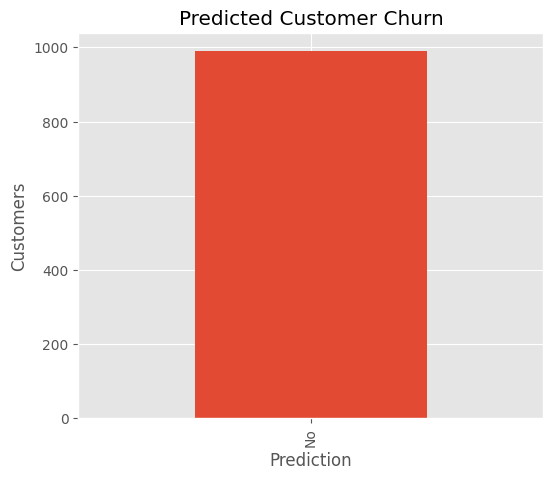

In [ ]:
import matplotlib.pyplot as plt

prediction_df["Predicted_Churn"].value_counts().plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Predicted Customer Churn")

plt.xlabel("Prediction")

plt.ylabel("Customers")

plt.show()